Classificacao de Instrumentos

In [46]:
import os
import sys
import joblib
import librosa
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import librosa.display
from pathlib import Path
from scipy.fftpack import dct
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

1. Carregamento

In [47]:
sys.path.append('../')
CLASSES = {'vio': 0, 'pia': 1, 'cla': 2}
BASE_PATH = os.path.abspath("../")

from utils.carregar_audio import carregar_audio 
from utils.extrair_atributos import extrair_atributos

In [48]:
def carregar_audio(caminho_arquivo, sr=22050):
    y, _ = librosa.load(caminho_arquivo, sr=sr)

    # normalizacao de amplitude
    y = y / (np.max(np.abs(y)) + 1e-8)
    return y

In [49]:
def plot_spectrum(y, sr, instrumento):
    Y = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), d=1/sr)

    plt.title(f"Espectrograma do {instrumento}")
    plt.plot(freqs, Y)
    plt.xlabel("Frequência (Hz)")
    plt.show()

In [54]:
def plot_espectrograma_comparativo(amostras, sr=22050):
    fig, axes = plt.subplots(1, len(amostras), figsize=(5 * len(amostras), 4))

    for ax, (y, instrumento) in zip(axes, amostras):
        Y = np.abs(np.fft.rfft(y))
        freqs = np.fft.rfftfreq(len(y), d=1/sr)
        ax.plot(freqs, Y)
        ax.set_title(f"Espectrograma — {instrumento}")
        ax.set_xlabel("Frequência (Hz)")
        ax.set_ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

In [56]:
def plot_mel_scale_comparativo(amostras, sr=22050, n_mels=128):
    fig, axes = plt.subplots(1, len(amostras), figsize=(5 * len(amostras), 4))

    for ax, (y, instrumento) in zip(axes, amostras):
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=n_mels)
        mel_mean = mel.mean(axis=1)          # média no tempo → 1 valor por banda Mel
        mel_db   = librosa.power_to_db(mel_mean, ref=np.max)
        mel_freqs = librosa.mel_frequencies(n_mels=n_mels, fmin=0, fmax=sr // 2)

        ax.plot(mel_freqs, mel_db)
        ax.set_title(f"Mel Scale — {instrumento}")
        ax.set_xlabel("Frequência (Hz)")
        ax.set_ylabel("Energia (dB)")
        ax.set_xscale("log")               # eixo X log → espaçamento Mel visível

    plt.tight_layout()
    plt.show()

In [59]:
def plot_espectro_linear_comparativo(amostras, sr=22050):
    fig, axes = plt.subplots(1, len(amostras), figsize=(5 * len(amostras), 4))

    for ax, (y, instrumento) in zip(axes, amostras):
        Y     = np.abs(np.fft.rfft(y))
        freqs = np.fft.rfftfreq(len(y), d=1/sr)
        Y_db  = 20 * np.log10(Y + 1e-8)

        ax.plot(freqs, Y_db)
        ax.set_title(f"Espectro Linear — {instrumento}")
        ax.set_xlabel("Frequência (Hz)")
        ax.set_ylabel("Magnitude (dB)")

    plt.tight_layout()
    plt.show()

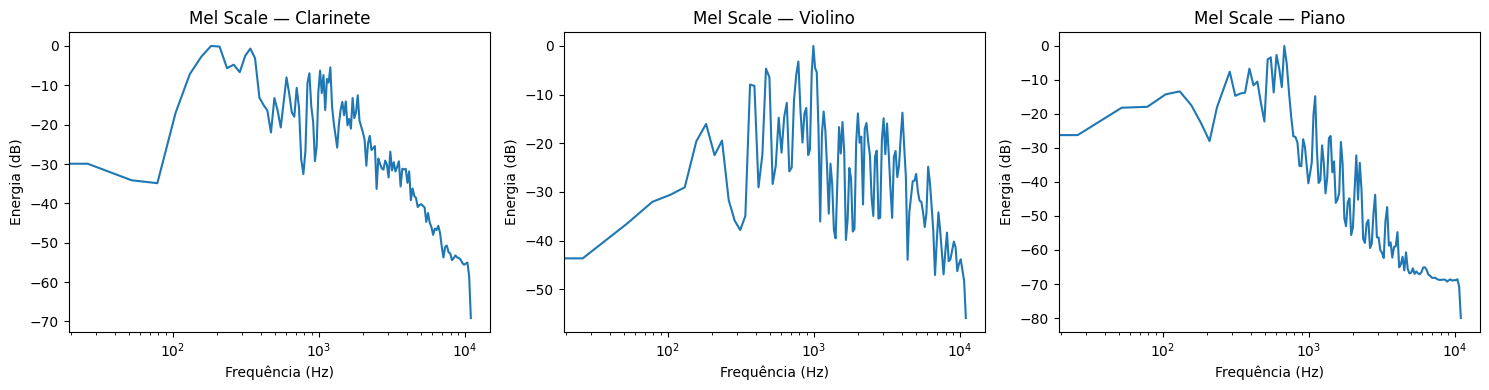

In [51]:
y_vio = carregar_audio(BASE_PATH + "/datasets/vio/" + "[vio][cla]2095__2.wav")
y_cla = carregar_audio(BASE_PATH + "/datasets/cla/" + "[cla][cla]0150__2.wav")
y_pia = carregar_audio(BASE_PATH + "/datasets/pia/" + "[pia][cla]1283__2.wav")

In [52]:
y_pia

array([ 0.07001851,  0.08726916,  0.05531862, ..., -0.25977692,
       -0.26035088, -0.1610971 ], shape=(66150,), dtype=float32)

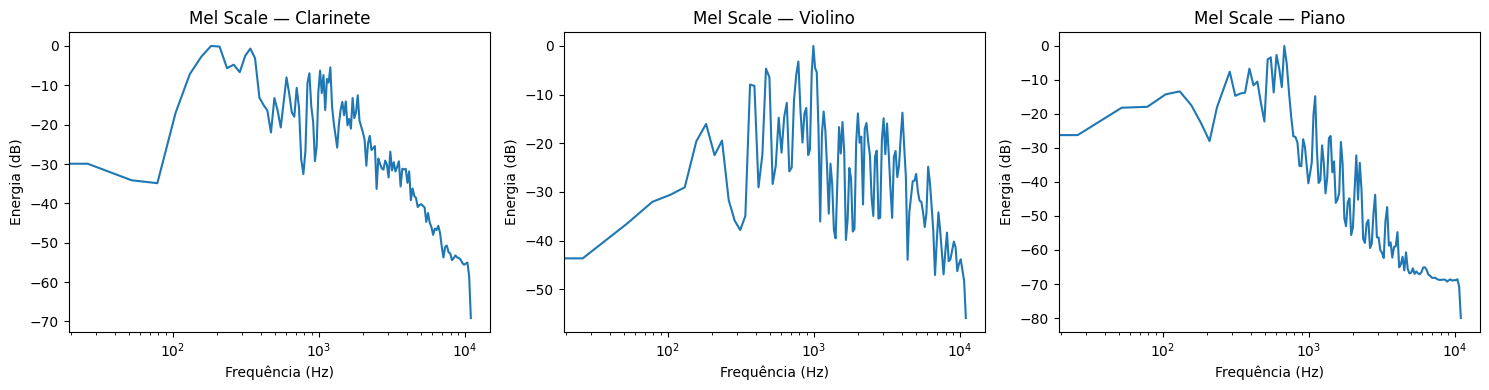

In [58]:
plot_mel_scale_comparativo([
    (y_cla, "Clarinete"),
    (y_vio, "Violino"),
    (y_pia, "Piano"),
])

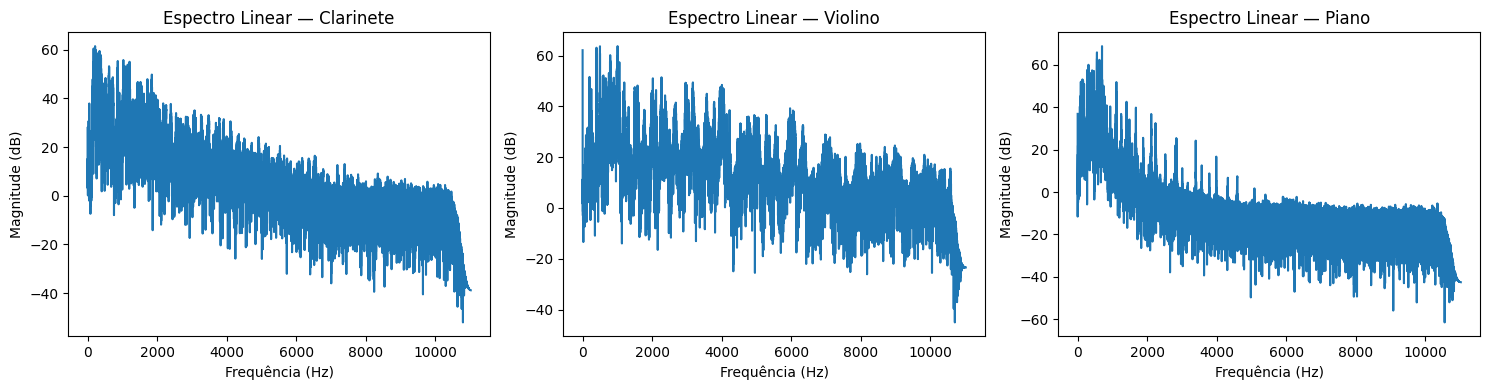

In [60]:
plot_espectro_linear_comparativo([
    (y_cla, "Clarinete"),
    (y_vio, "Violino"),
    (y_pia, "Piano"),
])

Espectogramas dos instrumentos

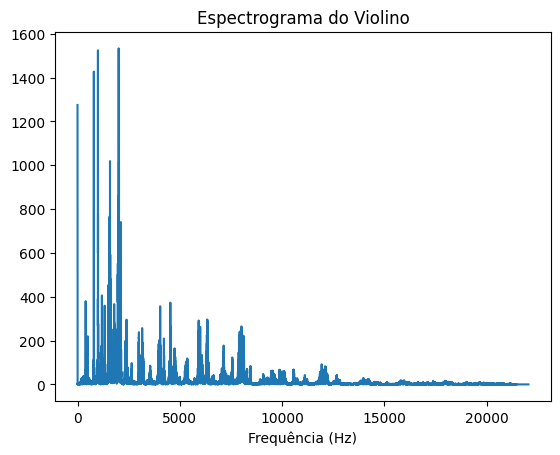

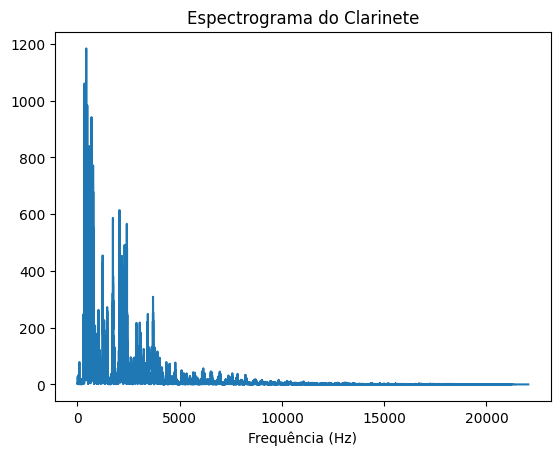

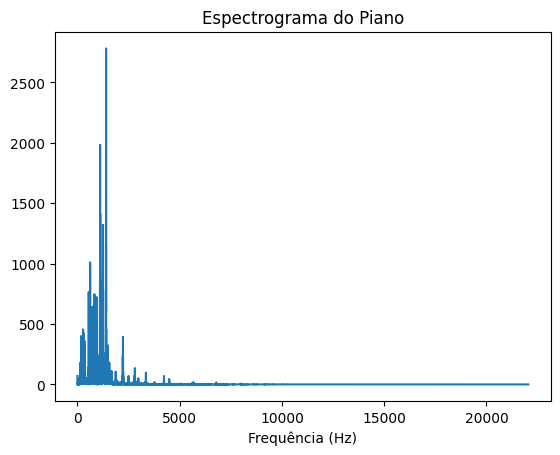

In [97]:
plot_spectrum(y_vio, 44100,instrumento="Violino")
plot_spectrum(y_cla, 44100,instrumento="Clarinete")
plot_spectrum(y_pia, 44100,instrumento="Piano")

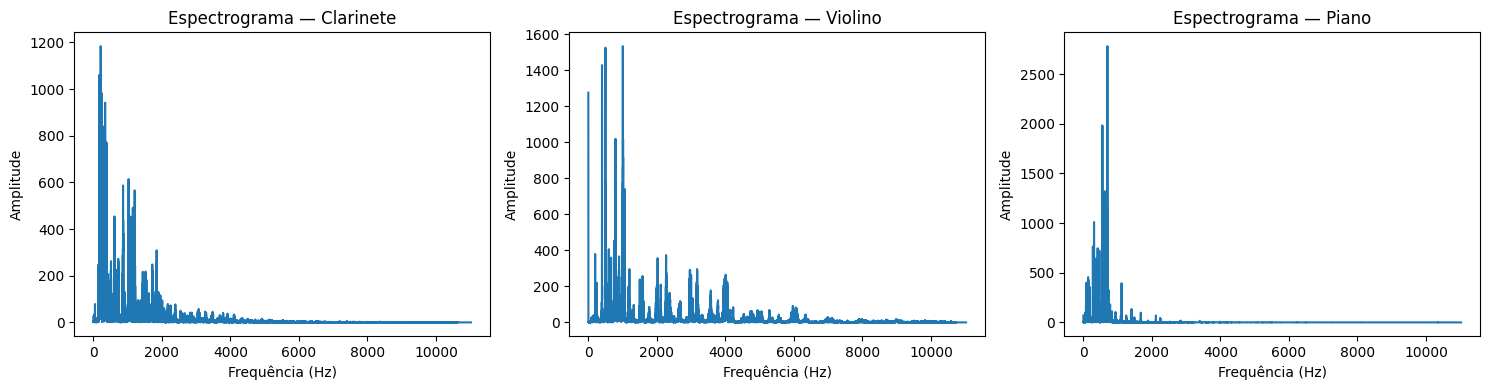

In [55]:
plot_espectrograma_comparativo([
    (y_cla, "Clarinete"),
    (y_vio, "Violino"),
    (y_pia, "Piano"),
])

Gráfico com frequência e limiares de f_max

piano: 100%|██████████| 721/721 [00:17<00:00, 40.67it/s]


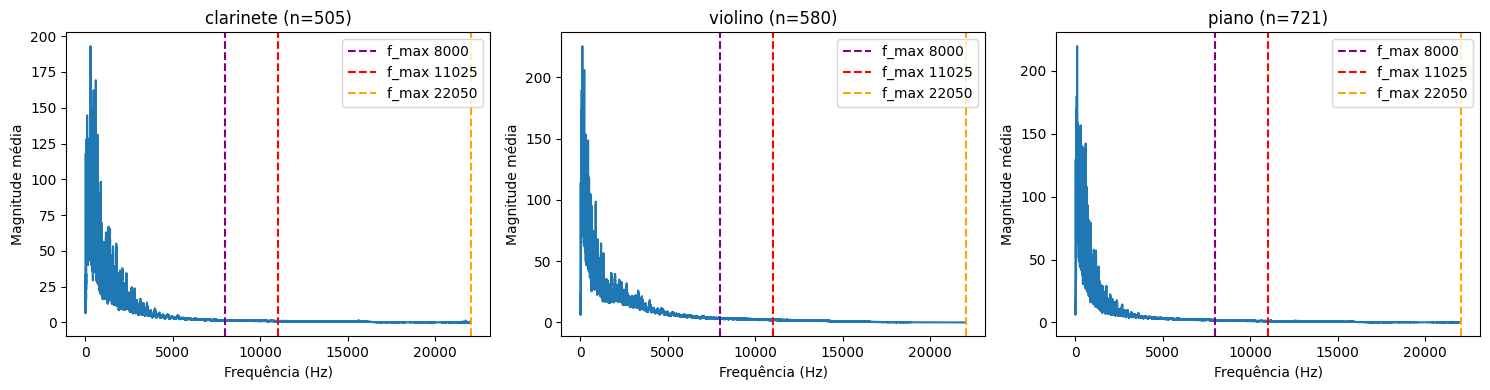

In [98]:
pastas = {
    'clarinete': BASE_PATH + '/datasets/cla',
    'violino':   BASE_PATH + '/datasets/vio',
    'piano':     BASE_PATH + '/datasets/pia'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, pasta) in zip(axes, pastas.items()):
    arquivos = [f for f in os.listdir(pasta) if f.endswith('.wav')]
    
    espectros = []
    for arquivo in tqdm(arquivos, desc=nome):
        caminho = os.path.join(pasta, arquivo)
        y, sr = librosa.load(caminho, sr=44100, mono=True, duration=3.0)
        Y = np.abs(np.fft.rfft(y))
        espectros.append(Y)
    
    Y_medio = np.mean(espectros, axis=0)
    freqs = np.fft.rfftfreq(len(y), d=1/sr)
    
    ax.plot(freqs, Y_medio)
    ax.axvline(8000, color="purple", linestyle='--', label='f_max 8000')
    ax.axvline(11025, color='red',    linestyle='--', label='f_max 11025')
    ax.axvline(22050, color='orange', linestyle='--', label='f_max 22050')
    ax.set_title(f'{nome} (n={len(arquivos)})')
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude média')
    ax.legend()

plt.tight_layout()
plt.show()

2. Extracao de Features

In [99]:
sr = 22050
fs = 2048   # n_fft
hs = 512    # hop_length
mfcc_dim = 13
ms = 128    # n_mels

def extract_feature(samples):
    result = []
    features = []

    # Timbre features
    spectral_centroid   = librosa.feature.spectral_centroid(y=samples, sr=sr, n_fft=fs, hop_length=hs)
    spectral_bandwidth  = librosa.feature.spectral_bandwidth(y=samples, sr=sr, n_fft=fs, hop_length=hs)
    spectral_contrast   = librosa.feature.spectral_contrast(y=samples, sr=sr, n_fft=fs, hop_length=hs)
    spectral_rolloff    = librosa.feature.spectral_rolloff(y=samples, sr=sr, n_fft=fs, hop_length=hs)
    spectral_flux       = librosa.onset.onset_strength(y=samples, sr=sr, center=True)
    zero_crossing       = librosa.feature.zero_crossing_rate(y=samples, frame_length=fs, hop_length=hs)

    # MFCCs (baseados na DCT — variante da DFT)
    mfcc = librosa.feature.mfcc(y=samples, sr=sr, n_fft=fs, hop_length=hs, n_mfcc=mfcc_dim)

    # Mel-spectrogram (representação 2D — "imagem" do sinal)
    mel_scale = librosa.feature.melspectrogram(y=samples, sr=sr, n_fft=fs, hop_length=hs, n_mels=ms)
    mel_scale = librosa.power_to_db(mel_scale)

    features.append(spectral_centroid)
    features.append(spectral_bandwidth)
    features.append(spectral_contrast)
    features.append(spectral_rolloff)
    features.append(spectral_flux)
    features.append(zero_crossing)

    for feature in features:
        result.append(np.mean(feature))
        result.append(np.std(feature))

    for i in range(mfcc_dim):
        result.append(np.mean(mfcc[i, :]))
        result.append(np.std(mfcc[i, :]))

    return result

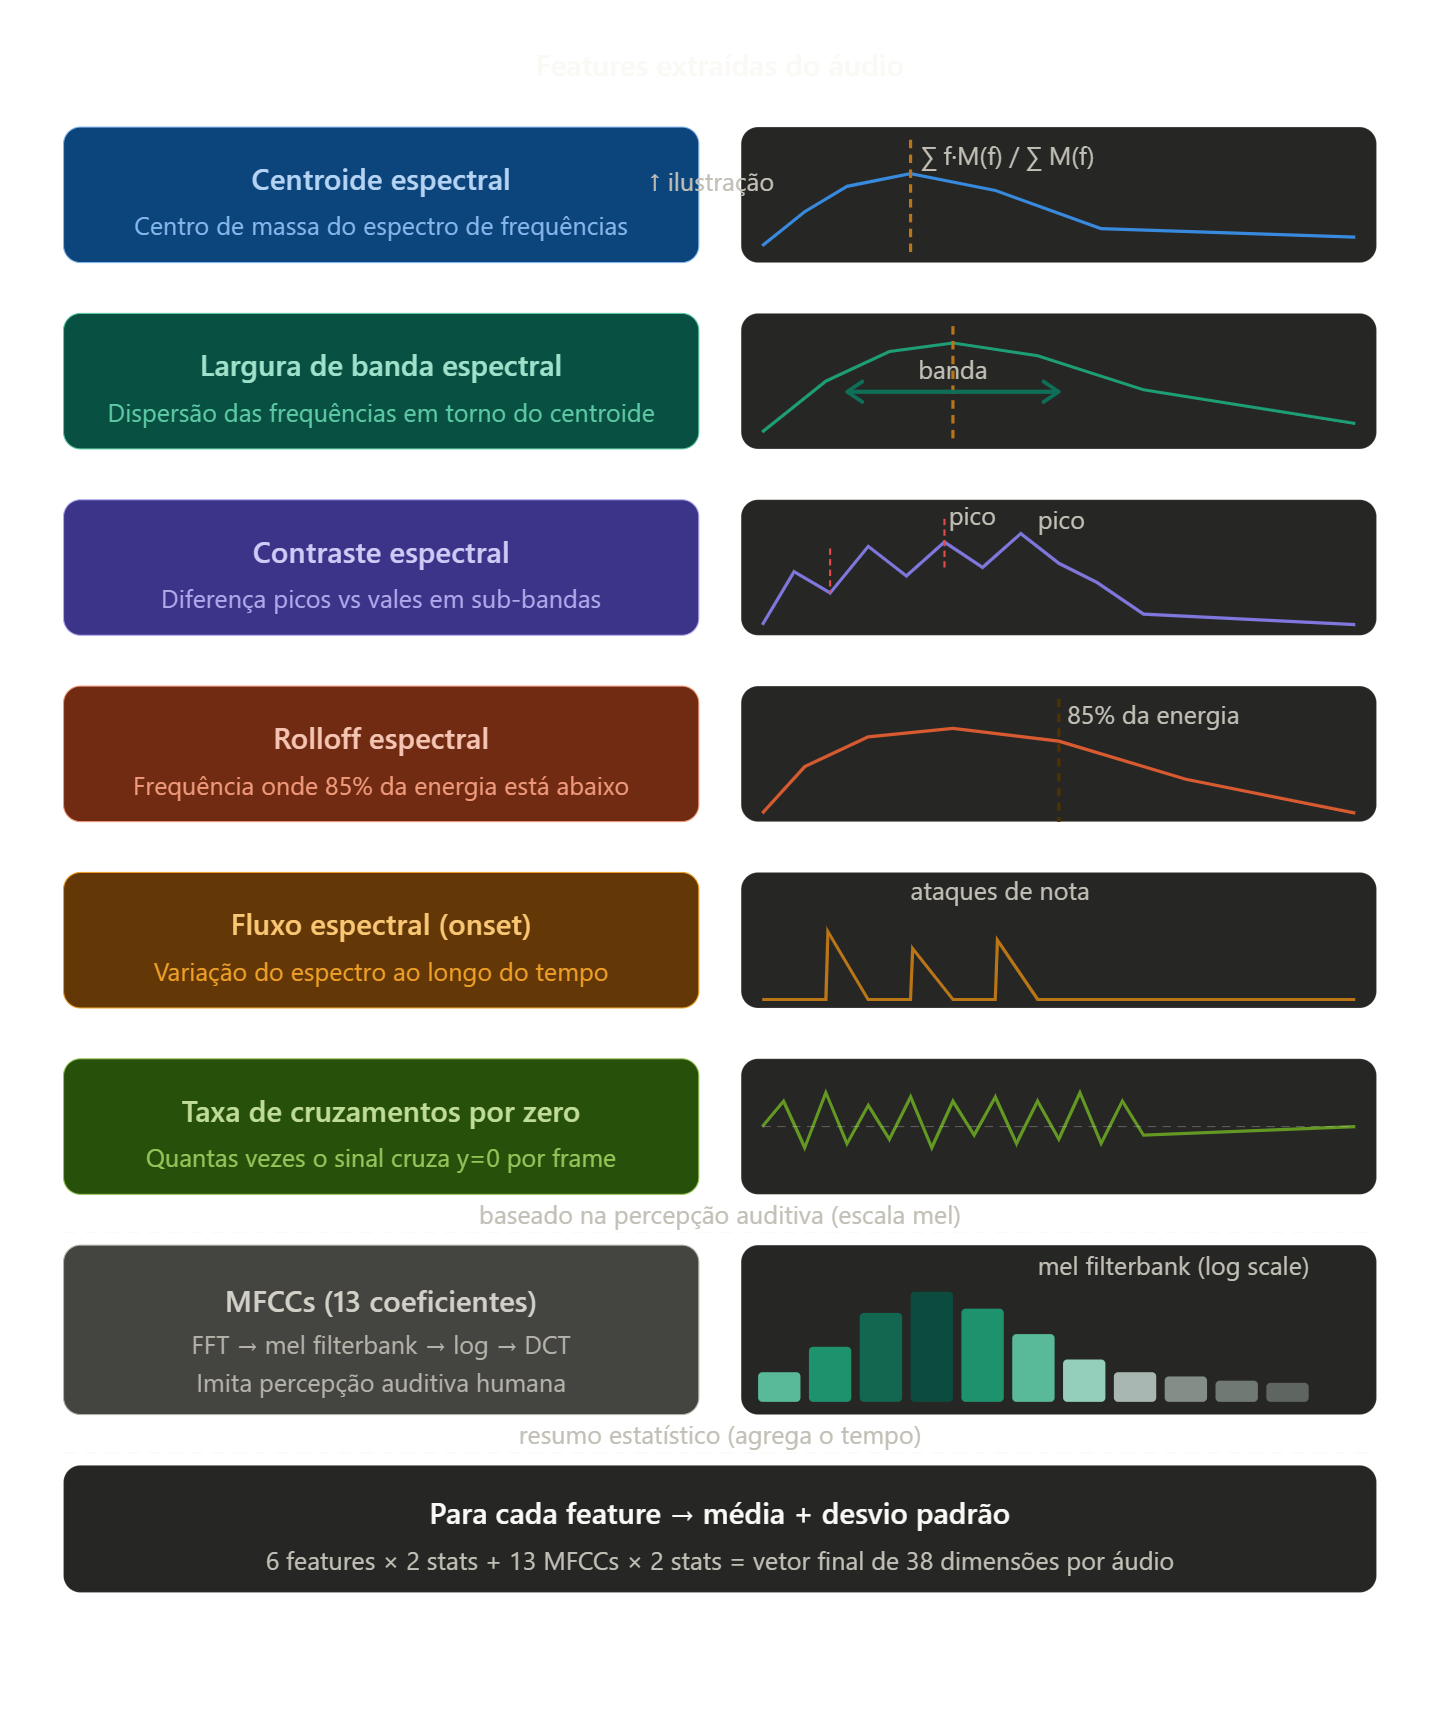

In [61]:
plt.savefig("espectro.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

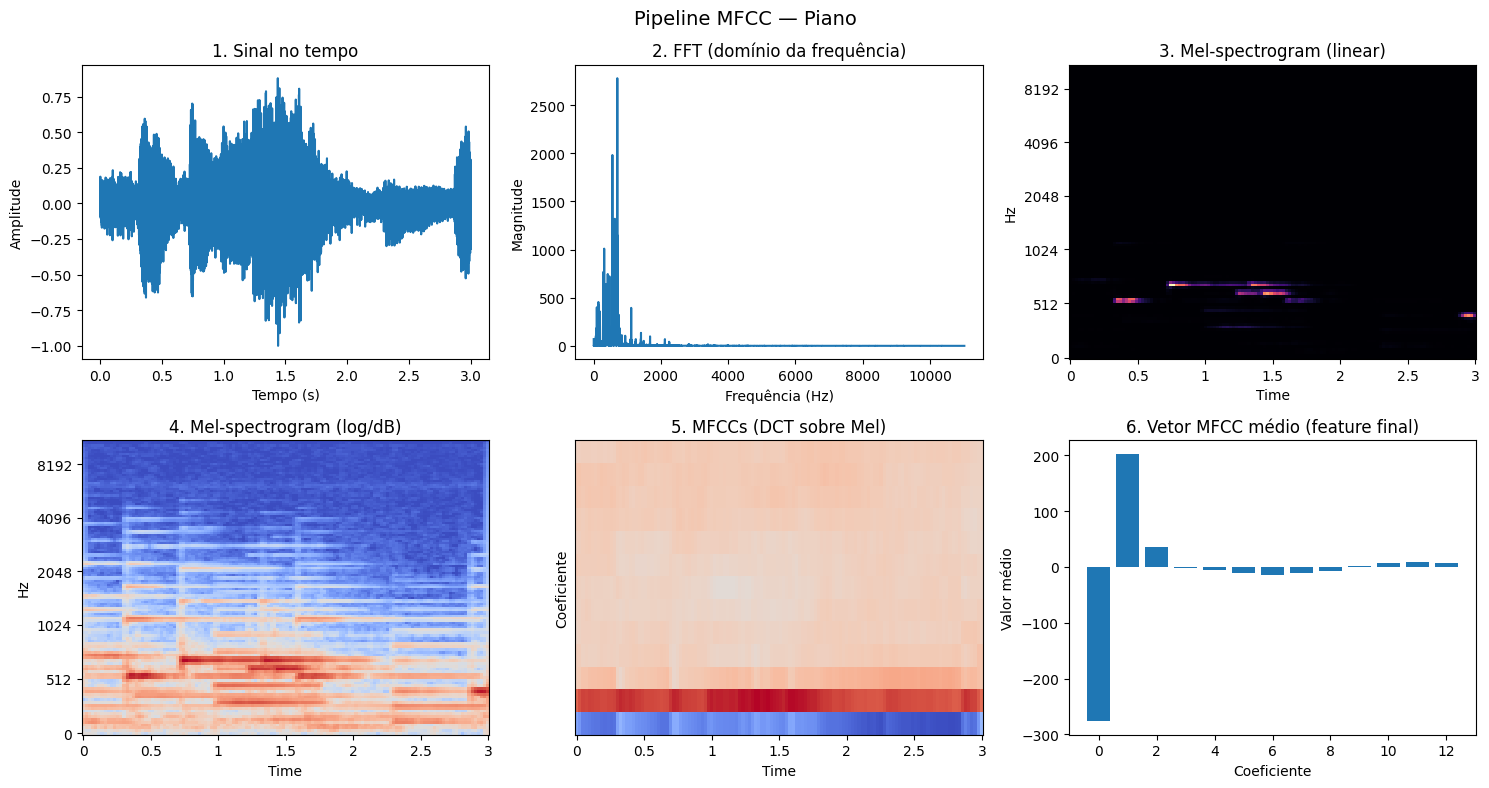

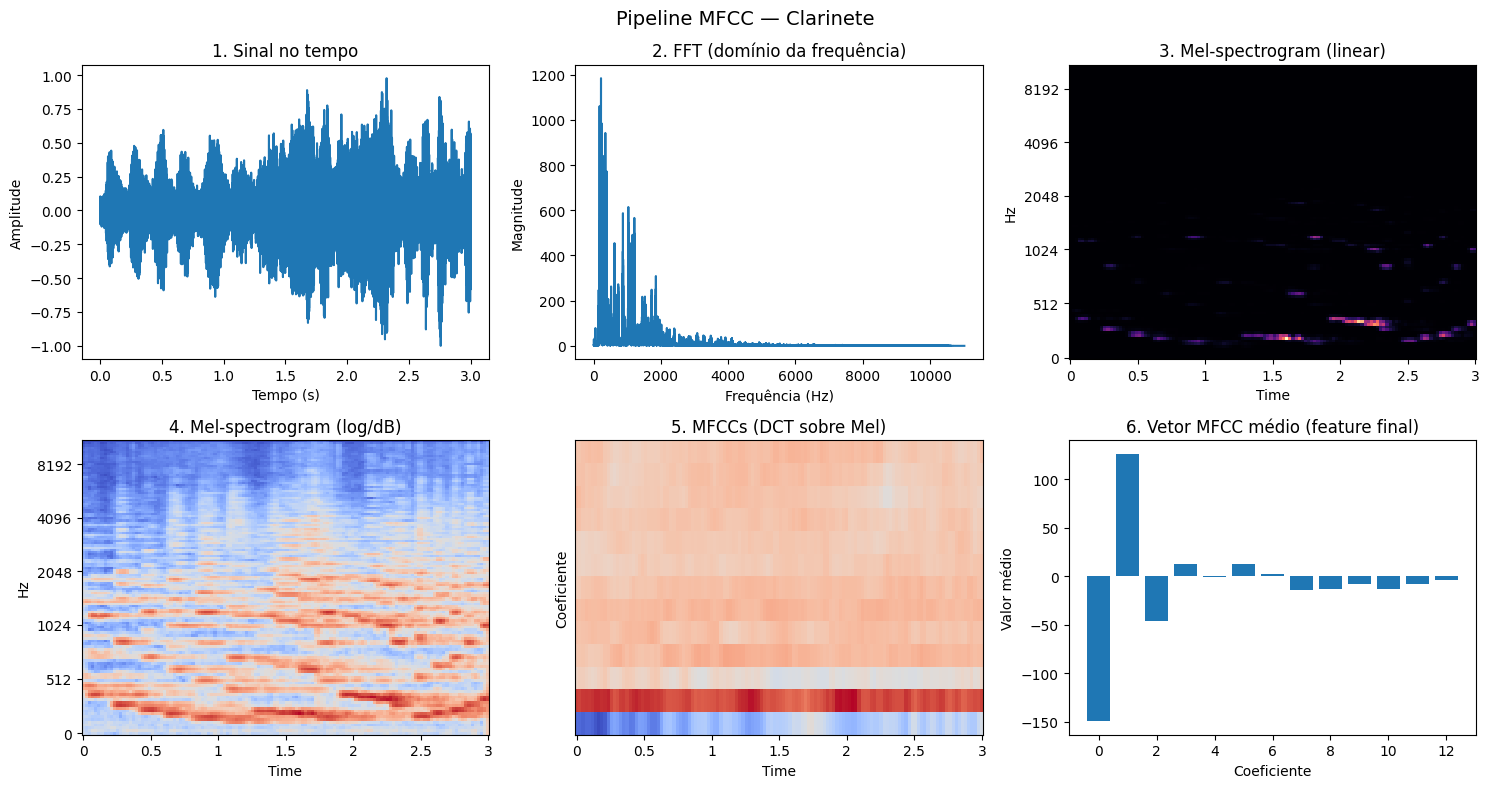

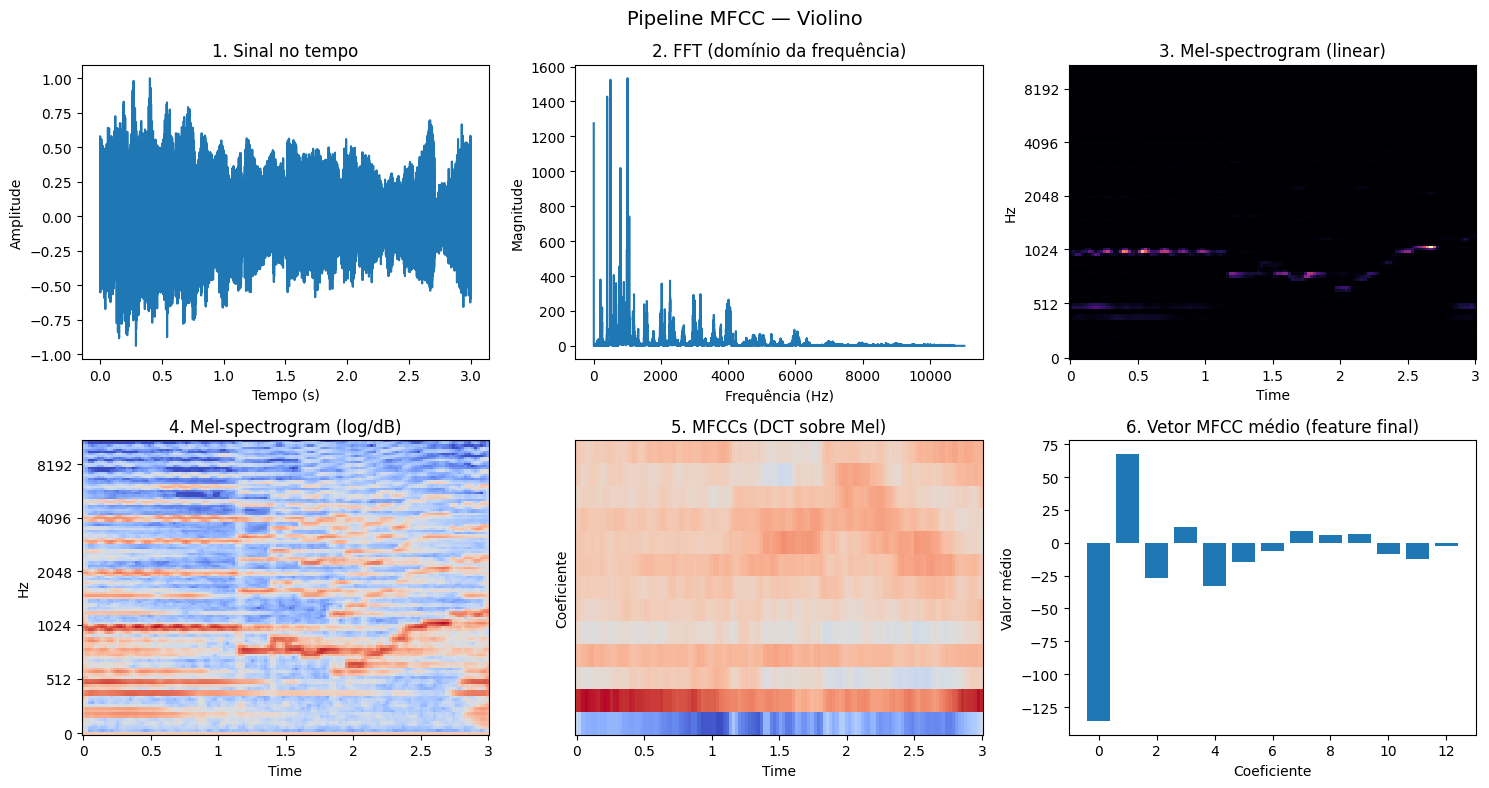

In [100]:
def plot_pipeline_mfcc(y, sr, instrumento, salvar=True):
    # --- ETAPA 1: Sinal no tempo ---
    # --- ETAPA 2: FFT ---
    Y = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), d=1/sr)

    # --- ETAPA 3: Mel filterbank ---
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)

    # --- ETAPA 4: Log (power_to_db) ---
    mel_db = librosa.power_to_db(mel)

    # --- ETAPA 5: DCT → MFCCs ---
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=2048, hop_length=512)

    # --- PLOT ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f'Pipeline MFCC — {instrumento}', fontsize=14)

    axes[0, 0].plot(np.linspace(0, len(y) / sr, len(y)), y)
    axes[0, 0].set_title('1. Sinal no tempo')
    axes[0, 0].set_xlabel('Tempo (s)')
    axes[0, 0].set_ylabel('Amplitude')

    axes[0, 1].plot(freqs, Y)
    axes[0, 1].set_title('2. FFT (domínio da frequência)')
    axes[0, 1].set_xlabel('Frequência (Hz)')
    axes[0, 1].set_ylabel('Magnitude')

    librosa.display.specshow(mel, sr=sr, hop_length=512,
                             x_axis='time', y_axis='mel', ax=axes[0, 2])
    axes[0, 2].set_title('3. Mel-spectrogram (linear)')

    librosa.display.specshow(mel_db, sr=sr, hop_length=512,
                             x_axis='time', y_axis='mel', ax=axes[1, 0])
    axes[1, 0].set_title('4. Mel-spectrogram (log/dB)')

    librosa.display.specshow(mfcc, sr=sr, hop_length=512,
                             x_axis='time', ax=axes[1, 1])
    axes[1, 1].set_title('5. MFCCs (DCT sobre Mel)')
    axes[1, 1].set_ylabel('Coeficiente')

    axes[1, 2].bar(range(13), np.mean(mfcc, axis=1))
    axes[1, 2].set_title('6. Vetor MFCC médio (feature final)')
    axes[1, 2].set_xlabel('Coeficiente')
    axes[1, 2].set_ylabel('Valor médio')

    plt.tight_layout()

    if salvar:
        plt.savefig(BASE_PATH + f'/resultados/pipeline_mfcc_{instrumento}.png', dpi=150)

    plt.show()


# usando os sinais já carregados
plot_pipeline_mfcc(y_pia, 22050, "Piano")
plot_pipeline_mfcc(y_cla, 22050, "Clarinete")
plot_pipeline_mfcc(y_vio, 22050, "Violino")

3. Montagem de dataset

In [109]:
def get_feature_names():
    names = []

    timbre_features = [
        'spectral_centroid', 'spectral_bandwidth',
        'spectral_contrast', 'spectral_rolloff',
        'spectral_flux', 'zero_crossing'
    ]

    for f in timbre_features:
        names.append(f'{f}_mean')
        names.append(f'{f}_std')

    for i in range(13):
        names.append(f'mfcc_{i}_mean')
        names.append(f'mfcc_{i}_std')

    return names  # 38 nomes no total


def build_dataset():
    rows = []
    col_names = get_feature_names()

    for classe, label in CLASSES.items():
        pasta_classe = Path(BASE_PATH) / "datasets" / classe
        arquivos_classe = sorted(pasta_classe.glob("*.wav"))

        for arquivo in tqdm(arquivos_classe, desc=classe):
            try:
                y = carregar_audio(str(arquivo))
                features = extract_feature(y)

                row = {
                    'arquivo': arquivo.name,
                    'instrumento': classe,
                    'label': label
                }
                row.update(dict(zip(col_names, features)))
                rows.append(row)
            except Exception as e:
                print(f"[ERRO] {arquivo}: {e}")

    return pd.DataFrame(rows)

In [110]:
df_features = build_dataset()

cla: 100%|██████████| 505/505 [00:31<00:00, 16.17it/s]


In [111]:
feature_cols = get_feature_names()

In [112]:
X = df_features[feature_cols].values   # shape: (n_amostras, 38)
y = df_features['label'].values  

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [114]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

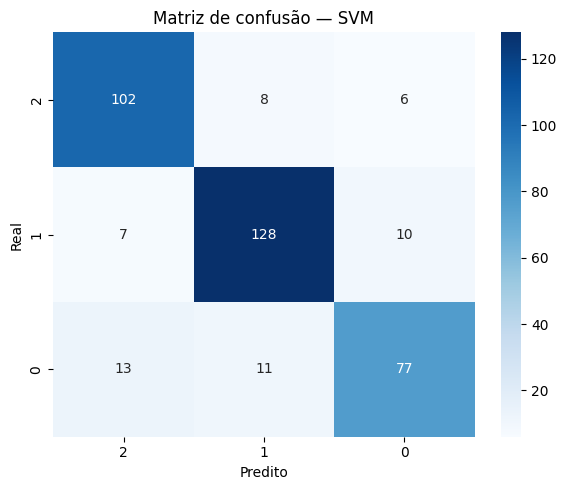

['scaler_instrumentos.pkl']

In [115]:
model = SVC(kernel='rbf', probability=True, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
labels = [CLASSES[i] for i in sorted(CLASSES)]

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels)
plt.title("Matriz de confusão — SVM")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.tight_layout()
plt.show()

joblib.dump(model,  "svm_instrumentos.pkl")
joblib.dump(scaler, "scaler_instrumentos.pkl")

In [117]:
print("\n── Relatório de classificação ──────────────────")
class_names = ["Violino", "Piano", "Clarinete"]
print(classification_report(y_test, y_pred, target_names=class_names))


── Relatório de classificação ──────────────────
              precision    recall  f1-score   support

     Violino       0.84      0.88      0.86       116
       Piano       0.87      0.88      0.88       145
   Clarinete       0.83      0.76      0.79       101

    accuracy                           0.85       362
   macro avg       0.84      0.84      0.84       362
weighted avg       0.85      0.85      0.85       362



In [118]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True, random_state=42)
)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro"
}

scores = cross_validate(
    cv_model,
    X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print(f"Acurácia (treino): {scores['train_accuracy'].mean():.4f} ± {scores['train_accuracy'].std():.4f}")
print(f"Acurácia (validação): {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
print(f"F1-macro (validação): {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")

Acurácia (treino): 0.9132 ± 0.0045
Acurácia (validação): 0.8416 ± 0.0216
F1-macro (validação): 0.8361 ± 0.0226
